<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Modulo 1: Introducción a Pytorch</h1>
    <h3>Aprendizaje Automático Avanzado</h3>
</div>

Hoy en día, cuando se desea crear un modelo de aprendizaje profundo, hay dos bibliotecas de aprendizaje automático que se deben tener en cuenta. La primera es **TensorFlow**, sobre la cual ya hemos hablado bastante, creada por Google y lanzada al público en 2015, ha sido la biblioteca líder durante años. La segunda es **PyTorch**, lanzada por Facebook en 2016. Aunque inicialmente estuvo muy por detrás, actualmente ambos marcos de trabajo están a la par y se utilizan con gran frecuencia.

**PyTorch** es una librería de código abierto para *Machine Learning* y *Deep Learning* que permite construir y entrenar redes neuronales de forma flexible e intuitiva. Es, junto con TensorFlow, uno de los dos frameworks más usados del mundo, y el preferido en la **investigación** en inteligencia artificial.

## Historia de PyTorch

PyTorch fue desarrollado por el laboratorio de investigación de inteligencia artificial de **Meta (Facebook AI Research, FAIR)** y se basa en la antigua biblioteca **Torch**, escrita en el lenguaje Lua.

| Año | Hito |
|---|---|
| **2002** | Aparece **Torch**, una biblioteca de cómputo científico basada en Lua. |
| **2016** | Facebook AI Research libera la primera versión de **PyTorch** (Python). |
| **2017** | Se populariza rápidamente en la comunidad de investigación por su enfoque *define-by-run*. |
| **2018** | Se fusiona con **Caffe2** para mejorar el despliegue en producción. |
| **2019** | Llega **PyTorch 1.0** con `TorchScript` para exportar modelos a producción. |
| **2022** | Se anuncia **PyTorch 2.0** con `torch.compile` para acelerar el entrenamiento. |
| **2022+** | El proyecto pasa a la **PyTorch Foundation** (bajo la Linux Foundation), con gobernanza abierta. |

Hoy PyTorch impulsa proyectos de investigación de vanguardia y sistemas en producción en empresas como Meta, Tesla, OpenAI, Microsoft y Uber.

## ¿Qué es PyTorch y por qué usarlo?

PyTorch se apoya en tres ideas fundamentales:

1. **Tensores**: arreglos multidimensionales similares a los de NumPy, pero que pueden ejecutarse en **GPU**.
2. **Autograd**: un motor de **diferenciación automática** que calcula gradientes por ti.
3. **Grafo computacional dinámico** (*define-by-run*) — el grafo se construye **sobre la marcha** a medida que se ejecuta el código.

### Grafo dinámico vs. grafo estático

```
   GRAFO ESTÁTICO (define-and-run)        GRAFO DINÁMICO (define-by-run)
   estilo clásico de TF 1.x               estilo de PyTorch

   1. Definir todo el grafo               1. Escribir código Python normal
   2. Compilarlo                          2. El grafo se crea al ejecutar
   3. Ejecutarlo con datos                3. Se puede usar if/for/while
                                             y depurar con print/pdb
```

> El grafo dinámico hace que PyTorch se sienta como **Python normal**: puedes usar bucles, condicionales y depurar con herramientas estándar.

## Algunas Ventajas de PyTorch

- **Pythónico e intuitivo:** se integra de forma natural con el ecosistema de Python (NumPy, pandas, Matplotlib).
- **Grafo dinámico:** flexibilidad total para arquitecturas complejas y depuración sencilla.
- **Autograd:** diferenciación automática sin escribir manualmente las derivadas.
- **Aceleración por GPU:** mover cómputo a la GPU es tan simple como `.to('cuda')`.
- **Ecosistema rico:** `torchvision` (visión), `torchaudio` (audio), `torchtext` (texto), `torchserve` (despliegue).
- **Comunidad e investigación:** la mayoría de los *papers* recientes publican su código en PyTorch.
- **Producción:** `TorchScript` y `torch.compile` permiten optimizar y exportar modelos.

### PyTorch vs. TensorFlow

|  | PyTorch | TensorFlow / Keras |
|---|---|---|
| **Creador** | Meta (FAIR) | Google |
| **Grafo** | Dinámico (define-by-run) | Estático/Dinámico (Eager en TF 2.x) |
| **Estilo** | Pythónico, control explícito | Alto nivel con Keras (`fit`) |
| **Depuración** | Sencilla (Python estándar) | Más indirecta |
| **Uso principal** | Investigación | Producción / industria |
| **Despliegue móvil** | PyTorch Mobile | TensorFlow Lite |

> Los **conceptos** (tensores, capas, optimizadores, retropropagación) son los mismos en ambos; solo cambia la sintaxis.

## Arquitectura y componentes de PyTorch

El siguiente **diagrama de bloques** resume los módulos principales de PyTorch y cómo se relacionan:

```
                         ┌─────────────────────────────────────────────┐
                         │                  PyTorch                     │
                         └─────────────────────────────────────────────┘
                                             │
        ┌───────────────┬───────────────────┼───────────────────┬────────────────┐
        ▼               ▼                   ▼                   ▼                ▼
 ┌────────────┐  ┌────────────┐     ┌──────────────┐   ┌──────────────┐  ┌──────────────┐
 │ torch      │  │ torch.     │     │ torch.nn     │   │ torch.optim  │  │ torch.utils. │
 │ (Tensores) │  │ autograd   │     │ (capas y     │   │ (optimiza-   │  │ data         │
 │            │  │ (gradien-  │     │  modelos)    │   │  dores)      │  │ (Dataset /   │
 │            │  │  tes)      │     │              │   │              │  │  DataLoader) │
 └────────────┘  └────────────┘     └──────────────┘   └──────────────┘  └──────────────┘
        │                                                                        │
        ▼                                                                        ▼
 ┌────────────────────────────────────────────┐              ┌──────────────────────────────┐
 │  Backend en C++/CUDA (rápido, en CPU o GPU)  │              │ torchvision · torchaudio ... │
 └────────────────────────────────────────────┘              └──────────────────────────────┘
```

| Componente | ¿Para qué sirve? |
|---|---|
| `torch` | Crear y operar **tensores** (la estructura de datos base). |
| `torch.autograd` | Calcular **gradientes** automáticamente (retropropagación). |
| `torch.nn` | Construir **redes neuronales** (capas, funciones de activación, pérdidas). |
| `torch.optim` | **Optimizadores** (SGD, Adam, RMSProp) para actualizar los pesos. |
| `torch.utils.data` | Manejar datos con `Dataset` y `DataLoader` (lotes, *shuffle*). |
| `torchvision`, `torchaudio`, `torchtext` | Utilidades específicas para visión, audio y texto. |

### El tensor: la estructura de datos central

Un **tensor** es una generalización de escalares, vectores y matrices a un número arbitrario de dimensiones:

```
  Escalar        Vector          Matriz             Tensor 3D
  (0-D)          (1-D)           (2-D)              (3-D)

    5          [5, 2, 7]       [[1, 2],           [[[..],[..]],
                               [3, 4],             [[..],[..]]]
                               [5, 6]]
  rank 0        rank 1          rank 2             rank 3
```

Cada tensor tiene tres propiedades fundamentales:
- **`shape`** — su forma (dimensiones).
- **`dtype`** — el tipo de dato (`float32`, `int64`, etc.).
- **`device`** — dónde vive (`cpu` o `cuda`).

## Instalación de PyTorch

La versión de CPU se instala fácilmente con `pip`. Para GPU (CUDA), consulta el configurador oficial en https://pytorch.org/get-started/locally/ (si instalamos nuestro enviroment no es necesario hacer esto)

!pip install torch torchvision torchaudio --user

In [1]:
import torch
import numpy as np

In [2]:
torch.__version__

'2.13.0+cpu'

## Crear tensores

Igual que en TensorFlow, todo en PyTorch gira en torno a los **tensores**. Empecemos creando tensores de distintas dimensiones (*rank*).

La forma más directa de crear un tensor es con `torch.tensor(...)`.

### Tensor de dimensión 0 (escalar)

In [3]:
# rank 0 (escalar)


tensor(1)
dim: 0 | shape: torch.Size([]) | dtype: torch.int64


Podemos definir un tensor con valores decimales o especificar explícitamente el tipo de dato con el argumento `dtype`.

In [4]:
# Decimal


tensor(1.2343)


### Tensor de dimensión 1 (vector)

In [5]:
# rank 1 (vector)


tensor([1, 2, 3, 4], dtype=torch.int16)


tensor([ True, False,  True])


### Tensor de dimensión 2 (matriz)

Para crear una matriz de 2 dimensiones, cerramos los corchetes después de cada fila.

In [7]:
# rank 2 (matriz)


tensor([[1, 2],
        [3, 4]], dtype=torch.int16)


#### Forma (shape) del tensor

La propiedad `.shape` (o `.size()`) devuelve las dimensiones del tensor.

tensor([[10, 11],
        [12, 13],
        [14, 15]])
shape: torch.Size([3, 2])


La matriz tiene 3 filas y 2 columnas.

PyTorch ofrece comandos útiles para crear tensores llenos de 0 o 1, o con valores aleatorios.

In [9]:
# Vector de ceros


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [10]:
# Matriz 3x3 de unos


tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


In [11]:
# Tensor aleatorio ~ N(0, 1) con la misma forma que m_shape


tensor([[ 0.0122, -0.3469],
        [ 1.1214,  1.2022],
        [-0.3356, -0.4160]])


### Tipo de datos (dtype)

Un tensor solo puede tener un tipo de dato a la vez. Puedes consultarlo con `.dtype` y convertirlo con `.to(...)` o `.type(...)`.

torch.int64

In [13]:
# Cambiar el tipo de dato (float -> int)


torch.float32 -> torch.int32 | valor: tensor(3, dtype=torch.int32)


## Operaciones con tensores

PyTorch incluye todas las operaciones matemáticas básicas. La mayoría existen como función (`torch.add`) y como operador (`+`).

tensor([1.4142])


A continuación, algunas operaciones de uso común. Cada una requiere uno o más argumentos.

- `torch.add(a, b)`
- `torch.sub(a, b)`
- `torch.mul(a, b)`
- `torch.div(a, b)`
- `torch.pow(a, b)`
- `torch.exp(a)`
- `torch.sqrt(a)`

In [15]:
# Suma


tensor([[5, 5]])


In [16]:
# Multiplicación elemento a elemento


tensor([[4, 6]])


In [17]:
# Producto matricial (matmul)


tensor([[ 4,  4],
        [10,  8]])


### Operaciones con un escalar

Al igual que en NumPy, las operaciones con un escalar se aplican a todos los elementos (*broadcasting*).

tensor([[3, 4],
        [5, 6]])
tensor([[ 5, 10],
        [15, 20]])


## Puente con NumPy

Los tensores de PyTorch y los arreglos de NumPy pueden convertirse entre sí fácilmente. En CPU, incluso **comparten memoria** (una copia es un *view*).

In [19]:
# De NumPy a PyTorch


tensor([[2, 3],
        [5, 8]])


In [20]:
# De PyTorch a NumPy


[[1 2]
 [3 4]]


## Autograd: diferenciación automática

El motor **`autograd`** construye un grafo de operaciones y aplica la regla de la cadena para obtener derivadas. Si una función escalar es $y=f(x)$, PyTorch conserva las operaciones necesarias para calcular $\frac{\partial y}{\partial x}$ cuando el tensor tiene `requires_grad=True`.

Para un tensor vectorial, `backward()` necesita una salida escalar o un gradiente externo. En general, si $y\in\mathbb{R}^m$ depende de $x\in\mathbb{R}^n$, el objeto matemático es el Jacobiano $J_{ij}=\partial y_i/\partial x_j$.

El gradiente se acumula en `.grad`. Por eso, antes de una nueva pasada hacia atrás, se debe limpiar con `.zero_()` o asignando `None`. Para cálculos que no necesitan derivadas se usa `torch.no_grad()`, lo que reduce memoria y trabajo.

In [3]:
# Derivar f(x) = x^3 - 2x + 1 en x = 2.


# f'(x) = 3x^2 - 2; en x=2, f'(2)=10.

# Las operaciones bajo no_grad no construyen un nuevo grafo.


f(x): 5.0
df/dx: 10.0
requires_grad con no_grad: False


### Descenso de gradiente sin redes neuronales

Podemos usar autograd para minimizar una función escalar sencilla. Consideremos:

$$J(w)=(w-3)^2+1$$

Su derivada es:

$$\frac{dJ}{dw}=2(w-3)$$

La actualización de descenso de gradiente es:

$$w_{t+1}=w_t-\eta\frac{dJ}{dw_t}$$

donde $\eta$ es la tasa de aprendizaje. El mínimo está en $w=3$, con $J(3)=1$. Este ejemplo ilustra el mecanismo de optimización sin construir ninguna red neuronal.

Valor final de w: 3.0000
Valor final de J(w): 1.0000


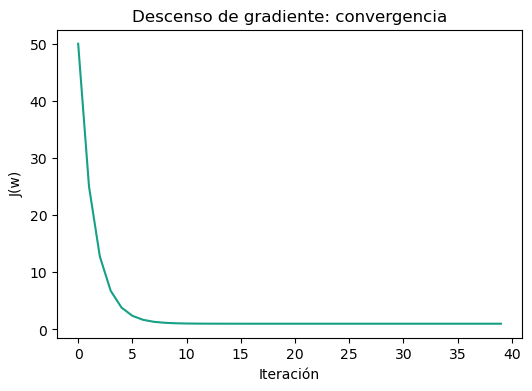

In [7]:
import matplotlib.pyplot as plt


## Datos y lotes: `Dataset` y `DataLoader`

Antes de entrenar cualquier modelo, necesitamos convertir los datos en un flujo reproducible. Un `Dataset` define cómo acceder a una observación; un `DataLoader` agrupa observaciones en lotes y puede barajarlas.

Para un conjunto de $n$ ejemplos, un lote de tamaño $B$ contiene aproximadamente $B$ observaciones por iteración. El número de lotes es:

$$\text{lotes}=\left\lceil\frac{n}{B}\right\rceil$$

`DataLoader` no realiza aprendizaje por sí mismo: solo organiza la lectura de datos, lo que permite separar claramente preparación, cálculo y optimización.

In [5]:
from torch.utils.data import Dataset, DataLoader



Tamaño del dataset: 20
Lote 0: x=torch.Size([5, 1]), y=torch.Size([5, 1])
Lote 1: x=torch.Size([5, 1]), y=torch.Size([5, 1])


## Validar gradientes con diferencias finitas

En depuración, un gradiente automático puede compararse con una aproximación numérica. Para una función $f$ y un paso pequeño $h$:

$$f'(x)\approx\frac{f(x+h)-f(x-h)}{2h}$$

Esta aproximación tiene error de truncamiento $O(h^2)$, pero si $h$ es demasiado pequeño aparecen errores de redondeo. La comparación numérica es una herramienta de diagnóstico, no el método que usaríamos para entrenar.

In [6]:
def funcion(x):
    return x**3 - 2 * x + 1


Gradiente automático: 6.670000076293945
Gradiente numérico: 6.667375564575195
Diferencia absoluta: 0.00262451171875


## Buenas prácticas antes de usar PyTorch en un proyecto

- Fija semillas cuando necesites experimentos reproducibles: `torch.manual_seed(42)` y, si procede, semillas de NumPy.
- Comprueba siempre `shape`, `dtype` y `device` antes de operar.
- Usa `float32` como punto de partida para cómputo eficiente; conserva `float64` solo si la precisión lo exige.
- Evita convertir repetidamente entre CPU, GPU, NumPy y PyTorch dentro de un ciclo.
- Usa `with torch.no_grad()` para inferencia o cálculos que no necesitan gradientes.
- Limpia los gradientes después de cada actualización cuando trabajes con autograd.
- Divide los datos en entrenamiento, validación y prueba cuando el objetivo sea evaluar generalización.
- Guarda la configuración experimental: semilla, dispositivo, versiones, hiperparámetros y transformaciones.


## CPU vs GPU: el atributo `device`

Los tensores de PyTorch pueden vivir y operar en la **CPU** o en la **GPU**. La convención es detectar el dispositivo disponible y mover ahí los datos que participarán en una misma operación con `.to(device)`.

No se pueden combinar directamente tensores que están en dispositivos distintos. Al terminar un cálculo en GPU, `.cpu()` devuelve una vista en CPU y `.numpy()` permite convertirla a NumPy cuando el tensor no requiere gradientes.

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Usando dispositivo:', device)

t_cpu = torch.tensor([1.0, 2.0, 3.0])
t_dev = t_cpu.to(device)   # mover a GPU si está disponible
print(t_dev, '| device:', t_dev.device)

Usando dispositivo: cpu
tensor([1., 2., 3.]) | device: cpu


### Formas, índices y operaciones vectorizadas

`reshape` cambia la forma sin cambiar el número de elementos. `unsqueeze` añade una dimensión de tamaño 1 y `squeeze` elimina dimensiones de tamaño 1. Estas operaciones son esenciales para que las dimensiones de entrada y salida sean compatibles.

Si $A\in\mathbb{R}^{m\times n}$ y $B\in\mathbb{R}^{n\times p}$, el producto matricial $AB$ pertenece a $\mathbb{R}^{m\times p}$ y:

$$ (AB)_{ij}=\sum_{k=1}^{n}A_{ik}B_{kj} $$

In [ ]:
base = torch.arange(12, dtype=torch.float32).reshape(3, 4)
print('base:\n', base)
print('primera fila:', base[0])
print('segunda columna:', base[:, 1])
print('forma con unsqueeze:', base.unsqueeze(0).shape)
print('forma con reshape:', base.reshape(2, 6).shape)
print('media por columnas:', base.mean(dim=0))
print('suma por filas:', base.sum(dim=1))


### Actividad propuesta

1. Cambia la función $J(w)$ por $J(w)=3(w+2)^2+0.5$.
2. Calcula simbólicamente su derivada y verifica el resultado con `autograd`.
3. Prueba tres tasas de aprendizaje y grafica la convergencia.
4. Cambia `batch_size` en el `DataLoader` y calcula cuántos lotes produce.
5. Explica por qué `requires_grad=True` no debe activarse para todos los datos de entrada sin necesidad.

> En el siguiente notebook se podrán introducir `torch.nn`, capas y redes neuronales. Aquí se han omitido deliberadamente para separar los fundamentos de PyTorch de la construcción de modelos.